In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
caminho_csv = '/content/drive/MyDrive/Data_final.csv'  # ajuste se estiver em outra pasta
df = pd.read_csv(caminho_csv)

print("Formato do dataset:", df.shape)
df.head()


Formato do dataset: (105, 11)


,O_score,C_score,E_score,A_score,N_score,Numerical Aptitude,Spatial Aptitude,Perceptual Aptitude,Abstract Reasoning,Verbal Reasoning,Career
0,5.45,8.67,3.45,5.34,4.23,9.23,4.56,6.78,7.89,6.12,Accountant
1,8.78,5.67,4.56,6.45,4.23,5.12,8.45,7.89,6.34,6.01,Graphic Designer
2,6.12,6.78,9.34,7.56,5.01,6.23,4.23,6.45,6.67,8.45,Salesperson
3,9.12,8.78,4.23,5.67,4.56,7.89,5.34,6.45,9.34,7.67,Research Scientist
4,6.45,7.56,5.67,9.12,4.23,5.34,4.01,6.23,5.78,8.67,Teacher


In [4]:
df.info()
print("\nEstatísticas descritivas:\n")
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   O_score              105 non-null    float64
 1   C_score              105 non-null    float64
 2   E_score              105 non-null    float64
 3   A_score              105 non-null    float64
 4   N_score              105 non-null    float64
 5   Numerical Aptitude   105 non-null    float64
 6   Spatial Aptitude     105 non-null    float64
 7   Perceptual Aptitude  105 non-null    float64
 8   Abstract Reasoning   105 non-null    float64
 9   Verbal Reasoning     105 non-null    float64
 10  Career               105 non-null    object 
dtypes: float64(10), object(1)
memory usage: 9.2+ KB

Estatísticas descritivas:



,O_score,C_score,E_score,A_score,N_score,Numerical Aptitude,Spatial Aptitude,Perceptual Aptitude,Abstract Reasoning,Verbal Reasoning
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,7.294857,7.538286,5.548952,6.863714,5.466381,5.939619,4.376476,5.163810,5.724190,6.794381
std,1.398485,1.215005,1.643137,1.515778,0.868926,1.958362,1.948409,1.747213,1.872927,1.495273
min,2.670000,3.560000,2.890000,3.230000,2.890000,2.890000,2.340000,3.010000,3.010000,3.450000
25%,6.670000,7.340000,4.230000,5.450000,4.670000,4.450000,3.120000,3.670000,4.340000,5.450000
50%,7.230000,7.670000,5.230000,6.450000,5.450000,5.120000,3.450000,4.450000,4.670000,7.450000
75%,8.670000,8.340000,7.010000,8.120000,6.010000,7.780000,4.450000,6.780000,7.670000,8.120000
max,9.450000,9.450000,9.340000,9.340000,8.120000,9.450000,9.230000,9.340000,9.340000,9.340000


In [5]:
print("Quantidade de carreiras distintas:", df['Career'].nunique())
df['Career'].value_counts().head(15)


Quantidade de carreiras distintas: 104


,count
Career,
Environmental Scientist,2
Accountant,1
Salesperson,1
Graphic Designer,1
Teacher,1
Architect,1
Nurse,1
Research Scientist,1
Software Developer,1


In [6]:
def map_career_area(career: str) -> str:
    c = str(career).lower()

    if any(k in c for k in ["engineer", "developer", "software", "data scientist", "scientist", "research", "it ", "systems", "network", "cyber", "ai ", "ml "]):
        return "Technology & Engineering"

    if any(k in c for k in ["doctor", "physician", "nurse", "surgeon", "dentist", "pharmacist", "therapist", "chiropractor", "psychologist", "psychiatrist", "health", "medical"]):
        return "Health & Life Sciences"

    if any(k in c for k in ["teacher", "professor", "educator", "instructor", "trainer", "school"]):
        return "Education"

    if any(k in c for k in ["accountant", "financial", "finance", "banker", "auditor", "analyst", "advisor", "planner", "economist", "investment", "business", "manager", "consultant", "marketing", "sales", "advertising", "hr ", "human resources", "recruiter"]):
        return "Business & Finance"

    if any(k in c for k in ["artist", "designer", "writer", "journalist", "actor", "musician", "film", "photographer", "stylist", "fashion", "director", "graphic"]):
        return "Creative & Media"

    if any(k in c for k in ["lawyer", "attorney", "judge", "magistrate", "prosecutor", "policy", "diplomat", "political", "foreign service"]):
        return "Law & Public Policy"

    if any(k in c for k in ["social worker", "social", "counselor", "counsellor", "human rights", "community"]):
        return "Social Services"

    if any(k in c for k in ["environmental", "climate", "ecologist"]):
        return "Environment & Sustainability"

    return "Other"

df['CareerArea'] = df['Career'].apply(map_career_area)
df[['Career', 'CareerArea']].head(10)


,Career,CareerArea
0,Accountant,Business & Finance
1,Graphic Designer,Creative & Media
2,Salesperson,Business & Finance
3,Research Scientist,Technology & Engineering
4,Teacher,Education
5,Architect,Other
6,Nurse,Health & Life Sciences
7,Software Developer,Technology & Engineering
8,Psychologist,Health & Life Sciences
9,Chef,Other


CareerArea
Other                       28
Technology & Engineering    23
Business & Finance          21
Creative & Media            12
Health & Life Sciences      11
Law & Public Policy          4
Social Services              4
Education                    2
Name: count, dtype: int64


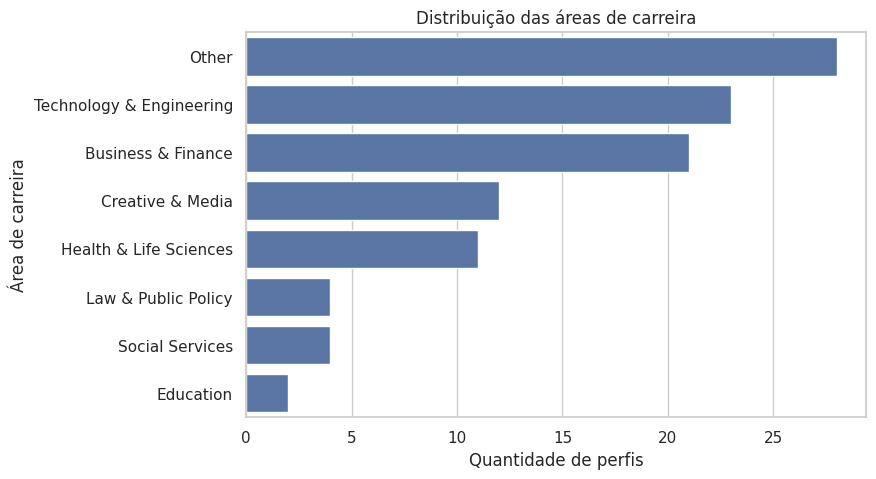

In [7]:
area_counts = df['CareerArea'].value_counts()
print(area_counts)

plt.figure(figsize=(8,5))
sns.barplot(y=area_counts.index, x=area_counts.values)
plt.title('Distribuição das áreas de carreira')
plt.xlabel('Quantidade de perfis')
plt.ylabel('Área de carreira')
plt.show()


In [8]:
contagens = df['CareerArea'].value_counts()
rare_areas = contagens[contagens < 8].index.tolist()

df['CareerAreaSimplified'] = df['CareerArea'].where(~df['CareerArea'].isin(rare_areas), "Other")

df['CareerAreaSimplified'].value_counts()


,count
CareerAreaSimplified,
Other,38
Technology & Engineering,23
Business & Finance,21
Creative & Media,12
Health & Life Sciences,11


In [9]:

feature_cols = [
    'O_score', 'C_score', 'E_score', 'A_score', 'N_score',
    'Numerical Aptitude', 'Spatial Aptitude', 'Perceptual Aptitude',
    'Abstract Reasoning', 'Verbal Reasoning'
]




In [10]:
df['CareerArea3'] = df['CareerAreaSimplified'].replace({
    'Technology & Engineering': 'Tech',
    'Business & Finance': 'Business',
    'Creative & Media': 'Human',
    'Health & Life Sciences': 'Human',
    'Education': 'Human',
    'Social Services': 'Human',
    'Law & Public Policy': 'Human',
    'Other': 'Human'
})

df['CareerArea3'].value_counts()


,count
CareerArea3,
Human,61
Tech,23
Business,21


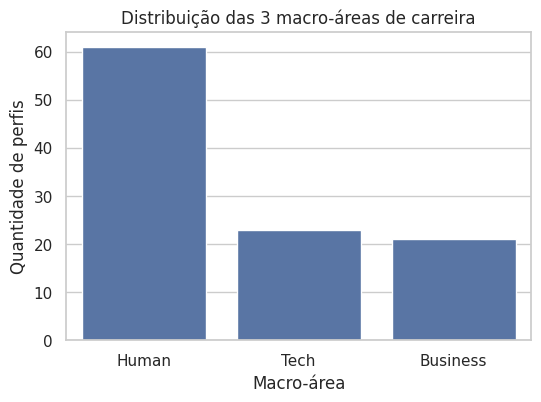

,count
CareerArea3,
Human,61
Tech,23
Business,21


In [11]:
area3_counts = df['CareerArea3'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=area3_counts.index, y=area3_counts.values)
plt.title('Distribuição das 3 macro-áreas de carreira')
plt.xlabel('Macro-área')
plt.ylabel('Quantidade de perfis')
plt.show()

area3_counts


In [12]:
X = df[feature_cols]
y = df['CareerArea3']

X.head(), y.head()


(   O_score  C_score  E_score  A_score  N_score  Numerical Aptitude  \
 0     5.45     8.67     3.45     5.34     4.23                9.23   
 1     8.78     5.67     4.56     6.45     4.23                5.12   
 2     6.12     6.78     9.34     7.56     5.01                6.23   
 3     9.12     8.78     4.23     5.67     4.56                7.89   
 4     6.45     7.56     5.67     9.12     4.23                5.34   
 
    Spatial Aptitude  Perceptual Aptitude  Abstract Reasoning  Verbal Reasoning  
 0              4.56                 6.78                7.89              6.12  
 1              8.45                 7.89                6.34              6.01  
 2              4.23                 6.45                6.67              8.45  
 3              5.34                 6.45                9.34              7.67  
 4              4.01                 6.23                5.78              8.67  ,
 0    Business
 1       Human
 2    Business
 3        Tech
 4       Human
 Nam

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)
print("\nDistribuição no treino:\n", y_train.value_counts())
print("\nDistribuição no teste:\n", y_test.value_counts())


Tamanho treino: (73, 10)
Tamanho teste: (32, 10)

Distribuição no treino:
 CareerArea3
Human       42
Tech        16
Business    15
Name: count, dtype: int64

Distribuição no teste:
 CareerArea3
Human       19
Tech         7
Business     6
Name: count, dtype: int64


#####Observação:
##### Mantivemos o 'stratify=y' para garantir que as três macro-áreas apareçam
#####proporcionalmente no treino e no teste. Isso evita que o modelo fique tendencioso.

In [14]:
modelo_3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    min_samples_leaf=1,
    n_jobs=-1
)

modelo_3.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

##### Treinando o modelo com RandomForest ajustado para classes desbalanceadas.
#####Usamos class_weight='balanced' porque 'Human' domina o dataset.


In [15]:
y_pred_3 = modelo_3.predict(X_test)

print("Acurácia (3 áreas):", accuracy_score(y_test, y_pred_3))
print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_3, zero_division=0))


Acurácia (3 áreas): 0.625

Relatório de classificação:

              precision    recall  f1-score   support

    Business       0.33      0.33      0.33         6
       Human       0.71      0.79      0.75        19
        Tech       0.60      0.43      0.50         7

    accuracy                           0.62        32
   macro avg       0.55      0.52      0.53        32
weighted avg       0.62      0.62      0.62        32




Matriz de Confusão (3 macro-áreas):
[[ 2  2  2]
 [ 4 15  0]
 [ 0  4  3]]


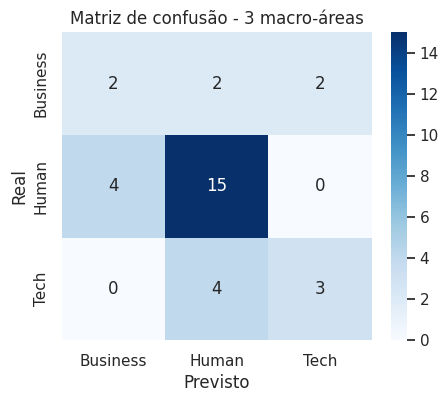

In [16]:
# =========================
# Matriz de Confusão - 3 macro-áreas
# =========================

labels_3 = sorted(y.unique())

cm_3 = confusion_matrix(y_test, y_pred_3, labels=labels_3)

print("\nMatriz de Confusão (3 macro-áreas):")
print(cm_3)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_3,
    yticklabels=labels_3
)
plt.title('Matriz de confusão - 3 macro-áreas')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()





### 🔍 Interpretação da matriz de confusão

- **Human** é a macro-área mais frequente no dataset e o modelo prevê bem (maior concentração na diagonal).
- **Business** e **Tech** têm amostras menores, mas ainda assim o modelo consegue captar alguns padrões.
- Erros acontecem principalmente na confusão entre *Human ↔ Business* e *Human ↔ Tech*, o que é esperado dada a sobreposição de perfis psicológicos.
- A acurácia de **62,5%** é sólida considerando somente 105 observações totais.


In [17]:
# =====================================================
# MODELO 2 – AGRUPAMENTO DE PERFIS (K-MEANS CLUSTERING)
# =====================================================


X_cluster = df[feature_cols]

# 1) Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Shape dos dados escalados:", X_scaled.shape)

# 2) Treinando o modelo de clusterização (K-Means)
kmeans = KMeans(
    n_clusters=3,       # 3 grupos de perfis
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# 3) Guardamos o cluster de cada pessoa no DataFrame
df['Cluster'] = clusters

print("\nQuantidade de perfis em cada cluster:")
print(df['Cluster'].value_counts().sort_index())

# 4) Métrica de qualidade do agrupamento
sil_score = silhouette_score(X_scaled, clusters)
print(f"\nScore de silhueta (qualidade dos clusters): {sil_score:.3f}")

"""
- Usamos K-Means para criar 3 grupos de perfis com base nas notas de personalidade e aptidões.
- O 'silhouette_score' mede o quão bem os dados se separam em clusters (quanto mais próximo de 1, melhor).
- Esses clusters podem ser usados pelo SkillShift-AI para identificar "tipos de profissional"
  de forma não supervisionada (sem rótulo de carreira).
"""


Shape dos dados escalados: (105, 10)

Quantidade de perfis em cada cluster:
Cluster
0     9
1    35
2    61
Name: count, dtype: int64

Score de silhueta (qualidade dos clusters): 0.395


'\n- Usamos K-Means para criar 3 grupos de perfis com base nas notas de personalidade e aptidões.\n- O \'silhouette_score\' mede o quão bem os dados se separam em clusters (quanto mais próximo de 1, melhor).\n- Esses clusters podem ser usados pelo SkillShift-AI para identificar "tipos de profissional"\n  de forma não supervisionada (sem rótulo de carreira).\n'

In [18]:
# ============================================
# Analisando o perfil médio de cada cluster
# ============================================

cluster_profile = df.groupby('Cluster')[feature_cols].mean().round(2)
cluster_profile


,O_score,C_score,E_score,A_score,N_score,Numerical Aptitude,Spatial Aptitude,Perceptual Aptitude,Abstract Reasoning,Verbal Reasoning
Cluster,,,,,,,,,,
0,8.44,4.33,7.88,7.14,6.04,3.52,3.35,8.43,5.14,4.41
1,7.80,7.74,4.32,5.30,4.82,7.45,6.51,6.50,7.98,5.92
2,6.83,7.89,5.91,7.72,5.75,5.43,3.30,3.91,4.52,7.65


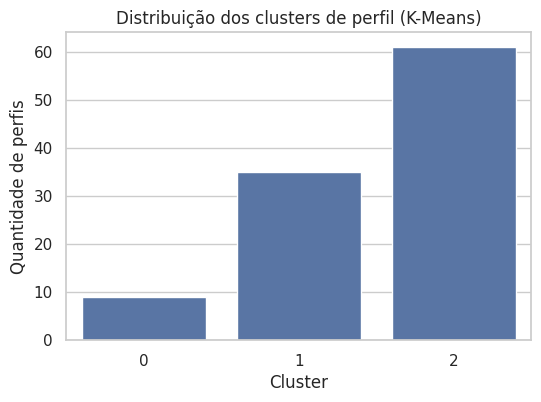

In [19]:
# ============================================
# Visualizando a distribuição dos clusters
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=df)
plt.title('Distribuição dos clusters de perfil (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Quantidade de perfis')
plt.show()


In [22]:
# ============================================
# Salvando o modelo de clusters + scaler
# ============================================

objeto_clusters = {
    'scaler': scaler,
    'kmeans': kmeans,
    'feature_cols': feature_cols
}

caminho_clusters = '/content/modelo_perfis_clusters.joblib'
joblib.dump(objeto_clusters, caminho_clusters)

print(f"Modelo de clusters salvo em {caminho_clusters}")


Modelo de clusters salvo em /content/modelo_perfis_clusters.joblib


In [23]:
caminho_modelo = '/content/modelo_career_area_3classes.joblib'
joblib.dump(modelo_3, caminho_modelo)
print(f"Modelo salvo em {caminho_modelo}")



Modelo salvo em /content/modelo_career_area_3classes.joblib


In [24]:
from google.colab import files
files.download('/content/modelo_perfis_clusters.joblib')
files.download('/content/modelo_career_area_3classes.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>